In [1]:
a=54
a

54

In [3]:
type(a)

int

In [5]:
b=4.5
b

4.5

In [7]:
type(b)

float

In [9]:
b

4.5

In [11]:
a

54

In [15]:
import cv2

def detect_faces_and_eyes():
    # Load the pre-trained Haar Cascade classifiers
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
    
    # Initialize webcam
    cap = cv2.VideoCapture(0)
    
    if not cap.isOpened():
        print("Error: Could not open webcam.")
        return
    
    while True:
        # Read frame from webcam
        ret, frame = cap.read()
        if not ret:
            print("Error: Could not read frame.")
            break
        
        # Convert to grayscale for detection
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # Detect faces
        faces = face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(30, 30)
        )
        
        # Draw rectangles around faces and detect eyes in each face
        for (x, y, w, h) in faces:
            # Draw rectangle around the face
            cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)
            
            # Region of Interest (ROI) for eyes detection (within the face)
            roi_gray = gray[y:y+h, x:x+w]
            roi_color = frame[y:y+h, x:x+w]
            
            # Detect eyes
            eyes = eye_cascade.detectMultiScale(
                roi_gray,
                scaleFactor=1.1,
                minNeighbors=5,
                minSize=(20, 20)
            )
            
            # Draw rectangles around the eyes
            for (ex, ey, ew, eh) in eyes:
                cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)
        
        # Display the output
        cv2.imshow('Face and Eye Detection', frame)
        
        # Exit on 'q' key press
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    # Release resources
    cap.release()
    cv2.destroyAllWindows()

def detect_in_image(image_path):
    # Load the image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return
    
    # Load the classifiers
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
    
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Detect faces
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )
    
    # Process each face
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)
        
        # ROI for eyes
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        
        # Detect eyes
        eyes = eye_cascade.detectMultiScale(
            roi_gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(20, 20)
        )
        
        # Draw eye rectangles
        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)
    
    # Display the result
    cv2.imshow('Image Detection', img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

if __name__ == "__main__":
    print("Face and Eye Detection Project")
    print("1. Real-time detection from webcam")
    print("2. Detect in an image file")
    choice = input("Enter your choice (1 or 2): ")
    
    if choice == '1':
        detect_faces_and_eyes()
    elif choice == '2':
        image_path = input("Enter the image file path: ")
        detect_in_image(image_path)
    else:
        print("Invalid choice. Exiting.")

Face and Eye Detection Project
1. Real-time detection from webcam
2. Detect in an image file


Enter your choice (1 or 2):  1


In [21]:
import cv2
import numpy as np

def detect_faces_eyes_smiles():
    # Load the pre-trained Haar Cascade classifiers
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
    smile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_smile.xml')
    
    # Initialize webcam
    cap = cv2.VideoCapture(0)
    
    if not cap.isOpened():
        print("Error: Could not open webcam.")
        return
    
    while True:
        # Read frame from webcam
        ret, frame = cap.read()
        if not ret:
            print("Error: Could not read frame.")
            break
        
        # Convert to grayscale for detection
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # Detect faces
        faces = face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.3,
            minNeighbors=5,
            minSize=(30, 30)
        )
        
        # Draw rectangles around faces and detect eyes/smiles in each face
        for (x, y, w, h) in faces:
            # Draw rectangle around the face
            cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)
            
            # Region of Interest (ROI) for eyes and smile detection
            roi_gray = gray[y:y+h, x:x+w]
            roi_color = frame[y:y+h, x:x+w]
            
            # Detect eyes
            eyes = eye_cascade.detectMultiScale(
                roi_gray,
                scaleFactor=1.1,
                minNeighbors=5,
                minSize=(20, 20)
            )
            
            # Draw rectangles around the eyes
            for (ex, ey, ew, eh) in eyes:
                cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)
            
            # Detect smiles (only in the lower half of the face)
            smile_roi_gray = roi_gray[int(h/2):h, 0:w]
            smile_roi_color = roi_color[int(h/2):h, 0:w]
            
            smiles = smile_cascade.detectMultiScale(
                smile_roi_gray,
                scaleFactor=1.7,
                minNeighbors=20,
                minSize=(25, 25)
            )
            
            # Draw rectangles around smiles
            for (sx, sy, sw, sh) in smiles:
                cv2.rectangle(smile_roi_color, (sx, sy), (sx+sw, sy+sh), (0, 0, 255), 2)
                cv2.putText(frame, 'Smile Detected', (x, y+h+30), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
        
        # Display the output
        cv2.imshow('Face, Eye, and Smile Detection', frame)
        
        # Exit on 'q' key press
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    # Release resources
    cap.release()
    cv2.destroyAllWindows()

def detect_in_image(image_path):
    # Load the image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return
    
    # Load the classifiers
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
    smile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_smile.xml')
    
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Detect faces
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.3,
        minNeighbors=5,
        minSize=(30, 30)
    )
    
    # Process each face
    for (x, y, w, h) in faces:
        # Draw rectangle around the face
        cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)
        
        # ROI for eyes and smile
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        
        # Detect eyes
        eyes = eye_cascade.detectMultiScale(
            roi_gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(20, 20)
        )
        
        # Draw eye rectangles
        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)
        
        # Detect smiles (lower half of face)
        smile_roi_gray = roi_gray[int(h/2):h, 0:w]
        smile_roi_color = roi_color[int(h/2):h, 0:w]
        
        smiles = smile_cascade.detectMultiScale(
            smile_roi_gray,
            scaleFactor=1.7,
            minNeighbors=20,
            minSize=(25, 25)
        )
        
        # Draw smile rectangles
        for (sx, sy, sw, sh) in smiles:
            cv2.rectangle(smile_roi_color, (sx, sy), (sx+sw, sy+sh), (0, 0, 255), 2)
            cv2.putText(img, 'Smile Detected', (x, y+h+30), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    
    # Display the result
    cv2.imshow('Image Detection', img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

if __name__ == "__main__":
    print("Face, Eye, and Smile Detection Project")
    print("1. Real-time detection from webcam")
    print("2. Detect in an image file")
    choice = input("Enter your choice (1 or 2): ")
    
    if choice == '1':
        detect_faces_eyes_smiles()
    elif choice == '2':
        image_path = input("Enter the image file path: ")
        detect_in_image(image_path)
    else:
        print("Invalid choice. Exiting.")

Face, Eye, and Smile Detection Project
1. Real-time detection from webcam
2. Detect in an image file


Enter your choice (1 or 2):  1


In [23]:
!pip install mediapipe

INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/51.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/51.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/51.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/51.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/51.0 MB 730.2 kB/s eta 0:01:10
    --------------------------------------- 0.8/51.0 MB 819.2 kB/s eta 0:01:02
    --------------------------------------- 1.0/51.0 MB 915.5 kB/s eta 0:00:55
   - -------------------------------------- 1.3/51.0 MB 1.0 MB/s eta 0:00:50
   - -------------------------------------- 1.6/51.0 MB 1.0 MB/s eta 0:00:48
   - -------------------------------------- 1.8/51.0 MB 1.1 MB/s eta 0:00:45
   - -------------------------------------- 2.1/51.0 MB 1.2 MB/s eta 0:00:43
   -- -----------

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'F:\\anacondaa\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.



In [25]:
import mediapipe as mp
print(mp.__version__)

ModuleNotFoundError: No module named 'mediapipe'

First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  Setosa  
1  Setosa  
2  Setosa  
3  Setosa  
4  Setosa  

Summary Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%          

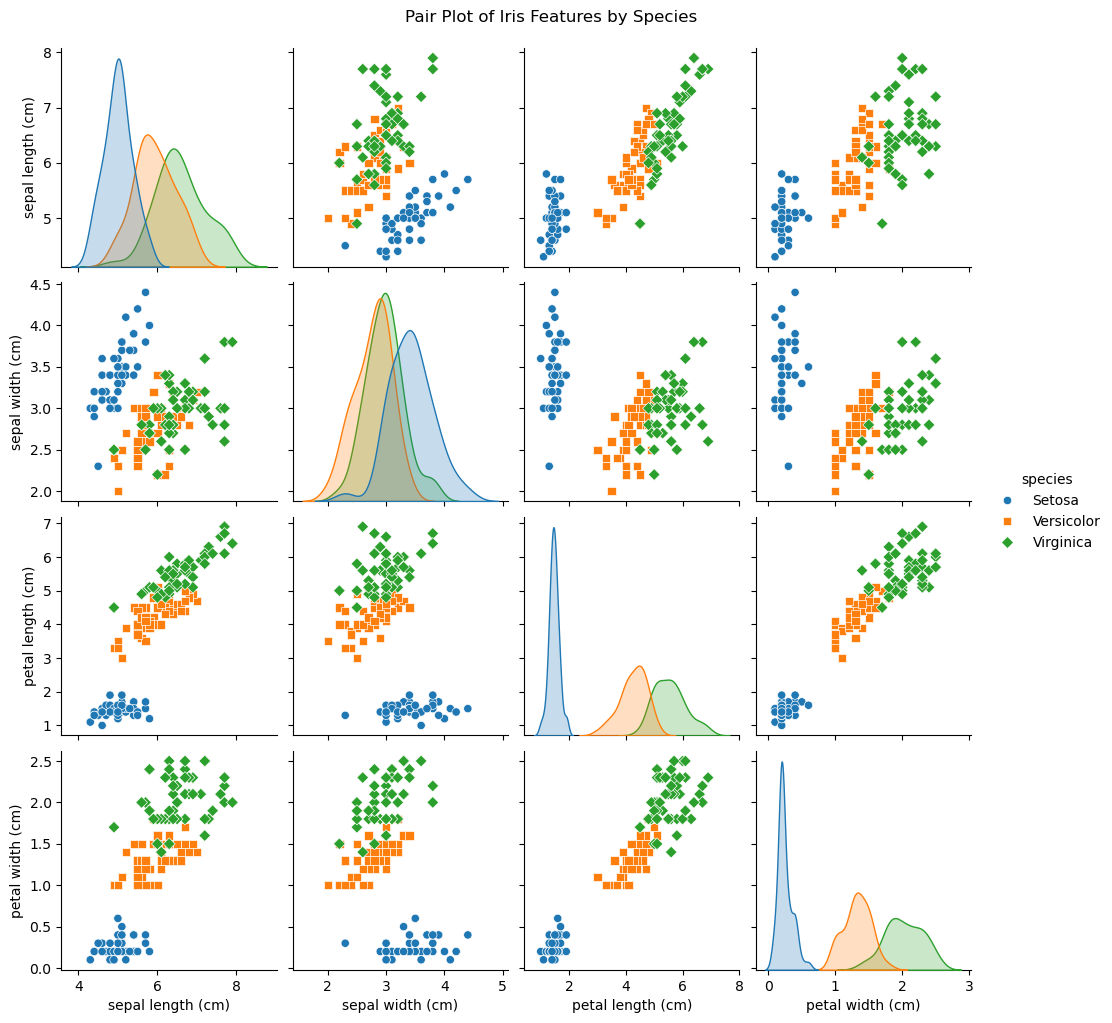


Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Accuracy: 100.00%

Predicted class for new sample: setosa


In [27]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load the Iris dataset
iris = load_iris()
X = iris.data  # Features (sepal length, sepal width, petal length, petal width)
y = iris.target  # Target labels (0: Setosa, 1: Versicolor, 2: Virginica)

# Convert to DataFrame for better visualization
iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df['species'] = y
iris_df['species'] = iris_df['species'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

# Exploratory Data Analysis (EDA)
print("First 5 rows of the dataset:")
print(iris_df.head())

print("\nSummary Statistics:")
print(iris_df.describe())

# Visualize the data
sns.pairplot(iris_df, hue='species', markers=['o', 's', 'D'])
plt.suptitle("Pair Plot of Iris Features by Species", y=1.02)
plt.show()

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (important for KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train a K-Nearest Neighbors (KNN) Classifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test)

# Evaluate the model
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy * 100:.2f}%")

# Test the model on a new sample
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])  # Example: Setosa
new_sample_scaled = scaler.transform(new_sample)
predicted_class = knn.predict(new_sample_scaled)
print(f"\nPredicted class for new sample: {iris.target_names[predicted_class][0]}")

In [29]:
!pip install yfinance pandas numpy matplotlib scikit-learn tensorflow prophet

  Using cached importlib_resources-6.5.2-py3-none-any.whl.metadata (3.9 kB)
   ---------------------------------------- 0.0/13.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.3 MB ? eta -:--:--
    --------------------------------------- 0.3/13.3 MB ? eta -:--:--
    --------------------------------------- 0.3/13.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/13.3 MB 730.2 kB/s eta 0:00:18
   -- ------------------------------------- 0.8/13.3 MB 745.8 kB/s eta 0:00:17
   --- ------------------------------------ 1.0/13.3 MB 839.3 kB/s eta 0:00:15
   --- ------------------------------------ 1.0/13.3 MB 839.3 kB/s eta 0:00:15
   --- ------------------------------------ 1.3/13.3 MB 883.4 kB/s eta 0:00:14
   --- ------------------------------------ 1.3/13.3 MB 883.4 kB/s eta 0:00:14
   ---- ----------------------------------- 1.6/13.3 MB 799.2 kB/s eta 0:00:15
   ---- -------------

In [31]:
# ========== IMPORTS ==========
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

# ========== DATA COLLECTION ==========
def get_stock_data(ticker, start_date, end_date):
    """Download historical stock data from Yahoo Finance"""
    data = yf.download(ticker, start=start_date, end=end_date)
    data = data[['Close']].reset_index()
    print(f"\nFirst 5 rows of {ticker} data:")
    print(data.head())
    return data

# ========== FEATURE ENGINEERING ==========
def create_features(data, window_size=5):
    """Create lagged features for time series prediction"""
    for i in range(1, window_size+1):
        data[f'Lag_{i}'] = data['Close'].shift(i)
    data.dropna(inplace=True)
    return data

# ========== LINEAR REGRESSION MODEL ==========
def linear_regression_model(X_train, X_test, y_train, y_test):
    """Train and evaluate Linear Regression model"""
    model = LinearRegression()
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    # Evaluation
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    print(f"\nLinear Regression Results:")
    print(f"MSE: {mse:.4f}")
    print(f"R² Score: {r2:.4f}")
    
    return predictions

# ========== LSTM MODEL ==========
def lstm_model(X_train, X_test, y_train, y_test):
    """Train and evaluate LSTM neural network"""
    # Scale data
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    y_train_scaled = scaler.fit_transform(y_train.values.reshape(-1, 1))
    y_test_scaled = scaler.transform(y_test.values.reshape(-1, 1))
    
    # Reshape for LSTM [samples, timesteps, features]
    X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
    X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])
    
    # Build LSTM model
    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=(1, X_train_reshaped.shape[2])),
        LSTM(50),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    
    # Train model
    model.fit(X_train_reshaped, y_train_scaled, epochs=20, batch_size=32, verbose=0)
    
    # Make predictions
    predictions = model.predict(X_test_reshaped)
    predictions = scaler.inverse_transform(predictions)
    y_test_actual = scaler.inverse_transform(y_test_scaled)
    
    # Evaluation
    mse = mean_squared_error(y_test_actual, predictions)
    print(f"\nLSTM Results:")
    print(f"MSE: {mse:.4f}")
    
    return predictions.flatten()

# ========== PROPHET MODEL ==========
def prophet_model(data, forecast_days=30):
    """Train and evaluate Facebook Prophet model"""
    df = data[['Date', 'Close']].rename(columns={'Date': 'ds', 'Close': 'y'})
    
    model = Prophet(daily_seasonality=True)
    model.fit(df)
    
    future = model.make_future_dataframe(periods=forecast_days)
    forecast = model.predict(future)
    
    print("\nProphet Forecast - Next 5 Days:")
    print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())
    
    return forecast

# ========== VISUALIZATION ==========
def plot_results(actual, pred_lr, pred_lstm, title):
    """Plot actual vs predicted prices"""
    plt.figure(figsize=(14, 7))
    plt.plot(actual.index, actual, label='Actual Price', color='blue')
    plt.plot(actual.index, pred_lr, label='Linear Regression', color='green')
    plt.plot(actual.index, pred_lstm, label='LSTM', color='red')
    plt.title(f'{title} - Price Prediction Comparison')
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.grid()
    plt.show()

# ========== MAIN EXECUTION ==========
if __name__ == "__main__":
    # Parameters
    TICKER = "AAPL"
    START_DATE = "2020-01-01"
    END_DATE = "2023-12-31"
    TEST_SIZE = 0.2
    LAG_WINDOW = 5
    
    # Step 1: Get data
    stock_data = get_stock_data(TICKER, START_DATE, END_DATE)
    
    # Step 2: Feature engineering
    feature_data = create_features(stock_data, LAG_WINDOW)
    
    # Prepare features and target
    X = feature_data[[f'Lag_{i}' for i in range(1, LAG_WINDOW+1)]]
    y = feature_data['Close']
    
    # Train-test split (without shuffling time series data)
    split_idx = int(len(X) * (1 - TEST_SIZE))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    # Step 3: Train and evaluate models
    lr_predictions = linear_regression_model(X_train, X_test, y_train, y_test)
    lstm_predictions = lstm_model(X_train, X_test, y_train, y_test)
    
    # Step 4: Prophet forecasting
    prophet_forecast = prophet_model(stock_data)
    
    # Step 5: Visualization
    plot_results(y_test, lr_predictions, lstm_predictions, TICKER)
    
    # Prophet forecast plot
    fig = plt.figure(figsize=(14, 7))
    plt.plot(stock_data['Date'], stock_data['Close'], label='Historical Price')
    plt.plot(prophet_forecast['ds'], prophet_forecast['yhat'], label='Prophet Forecast', color='orange')
    plt.fill_between(prophet_forecast['ds'], 
                    prophet_forecast['yhat_lower'], 
                    prophet_forecast['yhat_upper'], 
                    color='orange', alpha=0.2)
    plt.title(f'{TICKER} - Prophet 30-Day Forecast')
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.grid()
    plt.show()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed



First 5 rows of AAPL data:
Price        Date      Close
Ticker                  AAPL
0      2020-01-02  72.620834
1      2020-01-03  71.914810
2      2020-01-06  72.487839
3      2020-01-07  72.146935
4      2020-01-08  73.307510

Linear Regression Results:
MSE: 4.4993
R² Score: 0.9619
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step

LSTM Results:
MSE: 13.7247


TypeError: arg must be a list, tuple, 1-d array, or Series

In [33]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Function to download stock data
def get_stock_data(ticker, start_date, end_date):
    data = yf.download(ticker, start=start_date, end=end_date)
    return data[['Close']]

# Function to create features
def create_features(data, window=5):
    data = data.copy()
    data['SMA'] = data['Close'].rolling(window=window).mean()
    data['Previous_Close'] = data['Close'].shift(1)
    data.dropna(inplace=True)
    return data

# Main function
def main():
    # Parameters
    TICKER = 'AAPL'  # Apple stock
    START_DATE = '2020-01-01'
    END_DATE = '2023-12-31'
    TEST_SIZE = 0.2  # 20% for testing
    WINDOW = 5  # Moving average window
    
    # Get data
    stock_data = get_stock_data(TICKER, START_DATE, END_DATE)
    
    # Create features
    data = create_features(stock_data, WINDOW)
    
    # Prepare data for modeling
    X = data[['SMA', 'Previous_Close']]
    y = data['Close']
    
    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, shuffle=False)
    
    # Train linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Make predictions
    predictions = model.predict(X_test)
    
    # Evaluate model
    mae = mean_absolute_error(y_test, predictions)
    print(f"Mean Absolute Error: ${mae:.2f}")
    
    # Create DataFrame with results
    results = pd.DataFrame({
        'Actual': y_test,
        'Predicted': predictions,
        'Date': y_test.index
    }).set_index('Date')
    
    # Plot results
    plt.figure(figsize=(12, 6))
    plt.plot(results.index, results['Actual'], label='Actual Price', color='blue')
    plt.plot(results.index, results['Predicted'], label='Predicted Price', color='red')
    plt.title(f'{TICKER} Stock Price Prediction')
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.grid()
    plt.show()
    
    # Show last 5 predictions vs actual
    print("\nLast 5 days predictions vs actual:")
    print(results.tail())

if __name__ == "__main__":
    main()

[*********************100%***********************]  1 of 1 completed


Mean Absolute Error: $1.61


ValueError: Per-column arrays must each be 1-dimensional

In [35]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

def get_stock_data(ticker, days=60):
    """Get recent stock data"""
    data = yf.download(ticker, period=f"{days}d")
    return data[['Close']]

def predict_stock_price(ticker='AAPL'):
    # Get data
    data = get_stock_data(ticker)
    
    # Create features (using past 3 days)
    data['Day'] = range(len(data))  # Simple numeric feature
    data['Prev_Close'] = data['Close'].shift(1)
    data.dropna(inplace=True)
    
    # Prepare data
    X = data[['Day', 'Prev_Close']]
    y = data['Close']
    
    # Train model
    model = LinearRegression()
    model.fit(X, y)
    
    # Predict next day
    next_day = len(data)
    last_close = data['Close'].iloc[-1]
    prediction = model.predict([[next_day, last_close]])[0]
    
    # Plot results
    plt.figure(figsize=(10, 5))
    plt.plot(data.index, data['Close'], label='Actual Price')
    plt.axhline(prediction, color='red', linestyle='--', label=f'Predicted: ${prediction:.2f}')
    plt.title(f"{ticker} Stock Price Prediction")
    plt.xlabel("Date")
    plt.ylabel("Price ($)")
    plt.legend()
    plt.grid()
    plt.show()
    
    print(f"Predicted next closing price for {ticker}: ${prediction:.2f}")

# Run the prediction
predict_stock_price('AAPL')  # Change to any stock ticker

[*********************100%***********************]  1 of 1 completed


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (1, 2) + inhomogeneous part.

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseValue  
0    -122.23          4.526  
1    -122.22          3.585  
2    -122.24          3.521  
3    -122.25          3.413  
4    -122.25          3.422  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MedInc         20640 non-null  float64
 1   HouseAge       20640 non-null  float64
 2   AveRooms       20640 non-null  float64
 3   AveBedrms      20640 non-null 

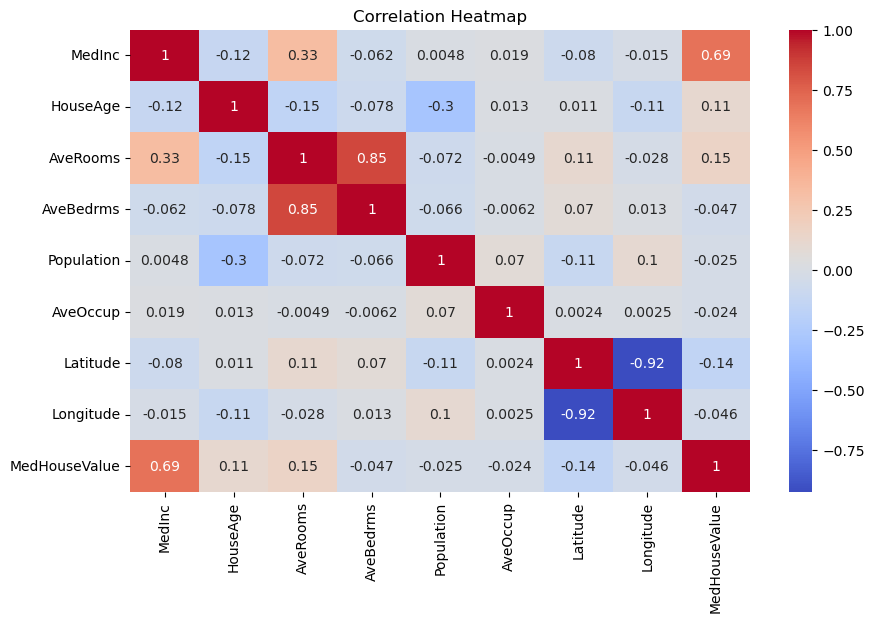

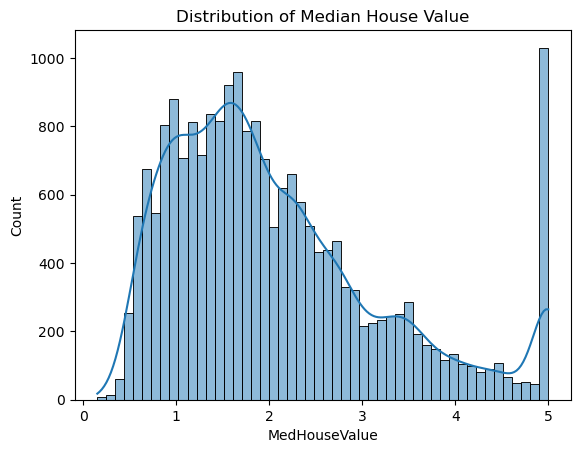

Mean Squared Error: 0.5559
R² Score: 0.5758


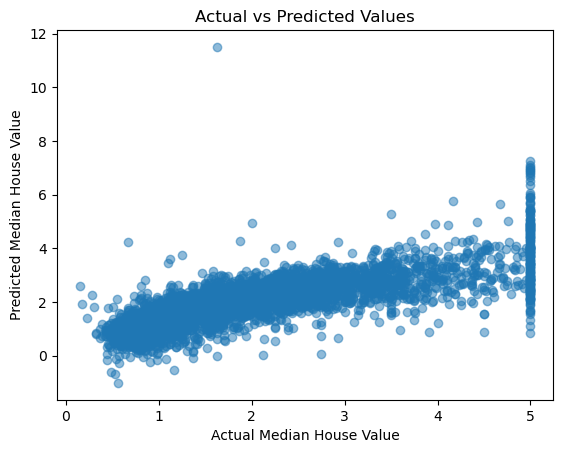

In [37]:
# Step 1: Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 2: Load California Housing Dataset
data = fetch_california_housing()
df = pd.DataFrame(data=data.data, columns=data.feature_names)
df['MedHouseValue'] = data.target

# Step 3: EDA - Exploratory Data Analysis
print(df.head())
print(df.info())
print(df.describe())
print("Missing Values:\n", df.isnull().sum())

# Visualize Correlation
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Distribution of Target Variable
sns.histplot(df['MedHouseValue'], bins=50, kde=True)
plt.title("Distribution of Median House Value")
plt.show()

# Step 4: Feature Selection and Train-Test Split
X = df.drop("MedHouseValue", axis=1)
y = df["MedHouseValue"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 6: Predict and Evaluate
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

# Step 7: Visualization of Prediction
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted Values")
plt.show()


[*********************100%***********************]  1 of 1 completed


Mean Squared Error: 6.4920
R² Score: 0.9919


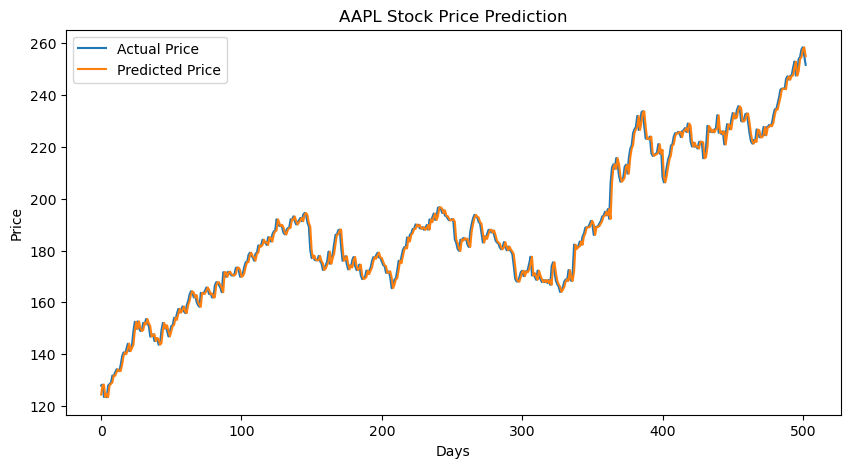

ValueError: Found array with dim 3. LinearRegression expected <= 2.

In [39]:
# Step 1: Install Required Library
# Run this line in Jupyter or first-time setup
# !pip install yfinance

# Step 2: Import Libraries
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 3: Download Stock Data
stock_symbol = 'AAPL'  # You can change this to 'GOOG', 'MSFT', etc.
data = yf.download(stock_symbol, start="2015-01-01", end="2024-12-31")

# Step 4: Preprocess Data
df = data[['Close']]
df = df.dropna()
df['Target'] = df['Close'].shift(-1)  # Predict next day's closing price
df.dropna(inplace=True)

# Step 5: Train-Test Split
X = df[['Close']]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Step 6: Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 7: Predict and Evaluate
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

# Step 8: Plot Predictions
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')
plt.title(f"{stock_symbol} Stock Price Prediction")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.show()

# Step 9: Predict Future Price
last_price = df['Close'].iloc[-1]
future_price = model.predict([[last_price]])
print(f"Predicted next price for {stock_symbol}: ${future_price[0]:.2f}")


[*********************100%***********************]  1 of 1 completed


Mean Squared Error: 7.7341
R2 Score: 0.9775


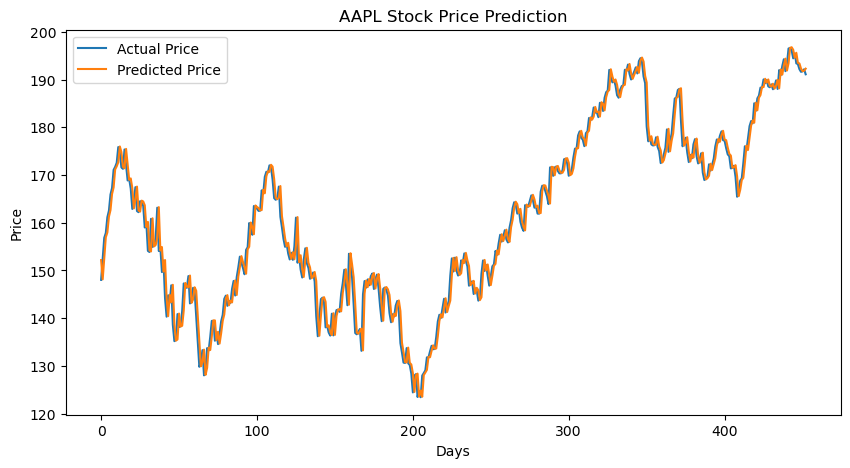

ValueError: Found array with dim 3. LinearRegression expected <= 2.

In [41]:
# Step 1: Install yfinance (if not already installed)
# You can uncomment and run this line once
# !pip install yfinance

# Step 2: Import required libraries
import yfinance as yf
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Step 3: Load stock data (e.g., Apple Inc.)
data = yf.download('AAPL', start='2015-01-01', end='2023-12-31')

# Step 4: Prepare data (only use closing prices)
df = data[['Close']].copy()
df['Target'] = df['Close'].shift(-1)  # Next day's close price
df.dropna(inplace=True)

# Step 5: Train-test split
X = df[['Close']]
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Step 6: Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 7: Predict and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", round(mse, 4))
print("R2 Score:", round(r2, 4))

# Step 8: Plot actual vs predicted prices
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')
plt.title('AAPL Stock Price Prediction')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.show()

# Step 9: Predict future price
last_price = df['Close'].iloc[-1]
predicted_price = model.predict([[last_price]])
print(f"Predicted Next Day Price: ${predicted_price[0]:.2f}")


In [43]:
import numpy as np

# Predict future stock price using the last known price
last_price = df['Close'].iloc[-1]
predicted_price = model.predict(np.array([[last_price]]))

print(f"Predicted Next Day Price: ${predicted_price[0]:.2f}")


ValueError: Found array with dim 3. LinearRegression expected <= 2.

[*********************100%***********************]  1 of 1 completed


Mean Squared Error: 7.73407023196491
R2 Score: 0.9774756131188389


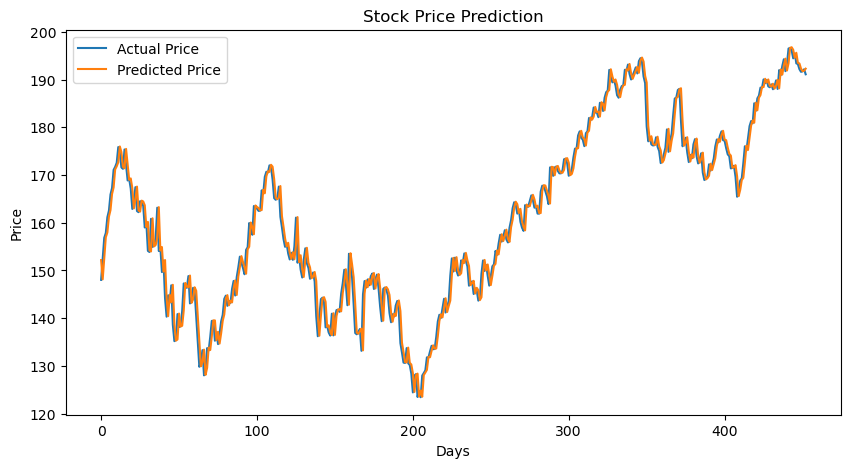

Predicted Next Day Price: $192.30


In [45]:
# ✅ Step 1: Install yfinance (only once)
# !pip install yfinance

# ✅ Step 2: Import libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# ✅ Step 3: Download stock data
data = yf.download('AAPL', start='2015-01-01', end='2023-12-31')

# ✅ Step 4: Prepare the DataFrame
df = data[['Close']].copy()
df['Target'] = df['Close'].shift(-1)  # Next day's price
df.dropna(inplace=True)

# ✅ Step 5: Split data
X = df[['Close']]         # Features
y = df['Target']          # Labels
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ✅ Step 6: Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# ✅ Step 7: Make predictions and evaluate
y_pred = model.predict(X_test)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# ✅ Step 8: Plot predictions
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')
plt.title('Stock Price Prediction')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.show()

# ✅ Step 9: Predict next day price safely
last_price = df[['Close']].iloc[-1].values.reshape(1, -1)  # 2D array shape
next_day_price = model.predict(last_price)

print(f"Predicted Next Day Price: ${next_day_price[0]:.2f}")


In [47]:
a=22
a

22

In [49]:
a

22

In [51]:
a

22

In [53]:
a

22

In [55]:
a

22

In [57]:
a

22

In [59]:
b=4.5
b

4.5

In [62]:
type(a)

int

In [64]:
type(b)

float

In [66]:
a

22

In [68]:
b

4.5

In [70]:
type(a)

int

In [72]:
type(b)

float

In [74]:
print(type(a))

<class 'int'>


In [76]:
print(type(b))

<class 'float'>


In [78]:
a

22

In [ ]:
b